In [32]:
# week1_lab_completed.py
# Completed Lab 1: Gradient Descent and KNN
# Implements tasks A1-A3 and B1-B5 as specified in LAB1_ML.pdf. :contentReference[oaicite:1]{index=1}

import numpy as np
import time
import matplotlib.pyplot as plt

In [ ]:
# ================================
# PART A — GRADIENT DESCENT
# ================================

def scalar_function(x):
    """f(x) = x^2 + 5"""
    return x**2 + 5

def scalar_gradient(x):
    """
    Analytical derivative of f(x) = x^2 + 5 is f'(x) = 2x.
    Task A1: implement derivative.
    """
    return 2.0 * x

def gradient_descent_scalar(x0, alpha, steps=20):
    """
    Performs gradient descent on scalar function f(x) starting at x0
    with step size alpha for `steps` iterations.
    Returns history of x values (before update appended each iter).
    """
    x = float(x0)
    history = []
    for _ in range(steps):
        history.append(x)
        grad = scalar_gradient(x)
        x = x - alpha * grad
    return np.array(history)

def surface_function(v):
    """f(x,y) = x^2 + 3 y^2"""
    x, y = v
    return x**2 + 3 * y**2

def surface_gradient(v):
    """
    Gradient vector for f(x,y) = x^2 + 3 y^2
    ∂f/∂x = 2x
    ∂f/∂y = 6y
    Task A2: implement gradient vector.
    """
    x, y = v
    return np.array([2.0 * x, 6.0 * y])

def gradient_descent_vector(v0, alpha, steps=20):
    """
    Performs multivariate gradient descent on the surface function.
    Returns array of history shape (steps, 2).
    """
    v = np.array(v0, dtype=float).copy()
    history = []
    for _ in range(steps):
        history.append(v.copy())
        grad = surface_gradient(v)
        v = v - alpha * grad
    return np.array(history)

def plot_trajectory(history, save_path=None):
    """
    Plots optimization trajectory for 2D gradient descent.
    history: array shape (steps, 2)
    """
    history = np.array(history)
    plt.figure(figsize=(6, 5))
    plt.plot(history[:, 0], history[:, 1], marker='o')
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Gradient Descent Trajectory")
    plt.grid(True)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


In [ ]:
# ================================
# PART B — KNN
# ================================

def generate_dataset(n=100, seed=42):
    """
    Synthetic 2D binary dataset (same as starter).
    """
    np.random.seed(seed)
    class0 = np.random.multivariate_normal([0, 0], np.eye(2), n//2)
    class1 = np.random.multivariate_normal([2, 2], np.eye(2), n//2)
    X = np.vstack([class0, class1])
    y = np.array([0]*(n//2) + [1]*(n//2))
    return X, y

def euclidean_distance_loop(x, y):
    """
    Compute Euclidean distance between two 1D vectors using a loop.
    Task B1: loop-based implementation.
    """
    assert x.shape == y.shape, "Vectors must have same shape"
    s = 0.0
    for xi, yi in zip(x, y):
        d = xi - yi
        s += d * d
    return np.sqrt(s)

def euclidean_distance_vectorized(x, y):
    """
    Compute Euclidean distance using numpy vectorized operations.
    Task B1: vectorized implementation (no loop).
    """
    diff = x - y
    return np.linalg.norm(diff)#linalg.norm computes the Euclidean norm (L2 distance) of the difference vector

def knn_predict(x_test, X_train, y_train, k):
    """
    KNN predict for a single test point x_test.
    Requirements from PDF:
    - compute distances (no loops)
    - use np.argpartition (no full sort)
    - majority vote and return predicted label
    """
    # Ensure shapes
    x_test = np.asarray(x_test)
    X_train = np.asarray(X_train)
    y_train = np.asarray(y_train)

    # Task B2: compute distances using broadcasting:
    # X_train - x_test produces shape (n_train, n_features) where each row is (x_i - x_test).
    # Taking norm along axis=1 yields vector of distances to x_test.
    distances = np.linalg.norm(X_train - x_test, axis=1)

    # Task B3: select k smallest indices using argpartition (O(n) average)
    # np.argpartition(distances, k) rearranges indices so that the first k indices are the k smallest distances (unsorted).
    # We then take the first k indices from the partitioned array.
    if k <= 0:
        raise ValueError("k must be >= 1")
    k = min(k, len(X_train))
    nearest_idx = np.argpartition(distances, k - 1)[:k]

    # Retrieve labels and perform majority vote
    neighbor_labels = y_train[nearest_idx]
    counts = np.bincount(neighbor_labels) #bincount counts occurrences of each label in neighbor_labels
    # In case of tie, np.argmax returns the smallest label among ties (deterministic tie-breaker)
    predicted = int(np.argmax(counts))
    return predicted, nearest_idx, distances


In [35]:
# ================================
# PERFORMANCE COMPARISON UTILITIES
# ================================

def time_function(func, *args, repeats=1000):
    start = time.time()
    for _ in range(repeats):
        func(*args)
    end = time.time()
    return end - start

def compare_distance_performance(dim=1000):
    x = np.random.rand(dim)
    y = np.random.rand(dim)

    loop_time = time_function(euclidean_distance_loop, x, y)
    vec_time = time_function(euclidean_distance_vectorized, x, y)

    print(f"Loop-based distance time: {loop_time:.6f}s")
    print(f"Vectorized distance time: {vec_time:.6f}s")
    print(f"Speedup: {loop_time / (vec_time + 1e-12):.2f}x")

def compare_knn_performance(n_samples=5000, n_features=10):
    X, y = generate_dataset(n_samples)
    x_test = X[0]

    # loop-based distances
    start = time.time()
    for i in range(len(X)):
        euclidean_distance_loop(x_test, X[i])
    loop_time = time.time() - start

    # vectorized distances
    start = time.time()
    _ = np.linalg.norm(X - x_test, axis=1)
    vec_time = time.time() - start

    print(f"KNN distance computation (loop): {loop_time:.6f}s")
    print(f"KNN distance computation (vectorized): {vec_time:.6f}s")
    print(f"Speedup: {loop_time / (vec_time + 1e-12):.2f}x")



=== PART A: Gradient Descent ===

Task A1: Scalar gradient descent on f(x)=x^2+5 with x0=10, steps=20
alpha=0.100 final x after 20 iters: 0.14411518807585588
 update factor r = 1 - 2*alpha = 0.800
  => Converges (|r| < 1).

alpha=1.000 final x after 20 iters: -10.0
 update factor r = 1 - 2*alpha = -1.000
  => Does not converge (|r| = 1) — oscillates or stays constant in magnitude.

alpha=1.100 final x after 20 iters: -319.4799993706238
 update factor r = 1 - 2*alpha = -1.200
  => Diverges (|r| > 1).

Task A2: 2D gradient descent on f(x,y)=x^2+3y^2 with (5,5), alpha=0.1
 iter  0: x=5.000000, y=5.000000
 iter  1: x=4.000000, y=2.000000
 iter  2: x=3.200000, y=0.800000
 iter  3: x=2.560000, y=0.320000
 iter  4: x=2.048000, y=0.128000
 iter  5: x=1.638400, y=0.051200
 iter  6: x=1.310720, y=0.020480
 iter  7: x=1.048576, y=0.008192
 iter  8: x=0.838861, y=0.003277
 iter  9: x=0.671089, y=0.001311

Explanation:
 For this surface, updates are x_{n+1} = (1 - 2*alpha) x_n and y_{n+1} = (1 - 6*

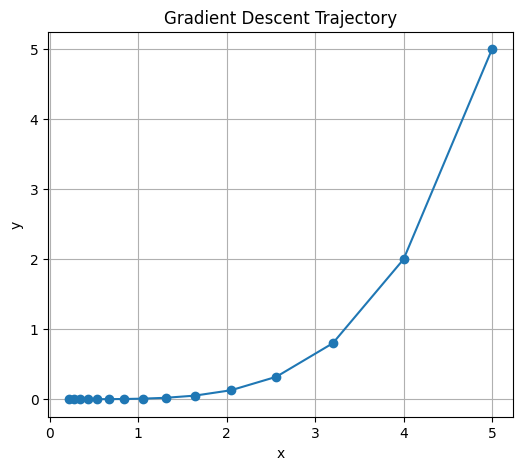

Saved plot to gd_trajectory.png (and displayed).

Task A3: Failure mode demonstration (scalar) with alpha=1.1 (expected diverge).
 iter  0: x = 1.000000e+01
 iter  1: x = -1.200000e+01
 iter  2: x = 1.440000e+01
 iter  3: x = -1.728000e+01
 iter  4: x = 2.073600e+01
 iter  5: x = -2.488320e+01
 iter  6: x = 2.985984e+01
 iter  7: x = -3.583181e+01
 iter  8: x = 4.299817e+01
 iter  9: x = -5.159780e+01
Explanation: update factor r = 1 - 2*alpha = 1 - 2*1.1 = -1.2 (|r| > 1) leads to magnitudes growing by factor 1.2 each iteration.

Task A3 (2D example): alpha=0.5 (x goes to 0 quickly, y diverges):
 iter  0: x=5.000000e+00, y=5.000000e+00
 iter  1: x=0.000000e+00, y=-1.000000e+01
 iter  2: x=0.000000e+00, y=2.000000e+01
 iter  3: x=0.000000e+00, y=-4.000000e+01
 iter  4: x=0.000000e+00, y=8.000000e+01
 iter  5: x=0.000000e+00, y=-1.600000e+02
 iter  6: x=0.000000e+00, y=3.200000e+02
 iter  7: x=0.000000e+00, y=-6.400000e+02
Explanation: x factor = 1 - 2*0.5 = 0 -> x becomes 0; y factor = 

In [ ]:
# ================================
# LAB RUNNER: run experiments required by the PDF
# ================================

def run_part_a():
    print("=== PART A: Gradient Descent ===\n")

    # A1: Scalar GD
    x0 = 10.0
    alphas = [0.1, 1.0, 1.1]
    steps = 20
    print("Task A1: Scalar gradient descent on f(x)=x^2+5 with x0=10, steps=20")
    for alpha in alphas:
        hist = gradient_descent_scalar(x0, alpha, steps=steps)
        final_x = hist[-1] # final x after 20 iterations
        print(f"alpha={alpha:0.3f} final x after {steps} iters: {final_x}")
        # explanation using factor r = 1 - 2*alpha
        r = 1 - 2 * alpha # r is the factor by which x scales each iteration: x_{n+1} = r * x_n
        print(f" update factor r = 1 - 2*alpha = {r:.3f}")
        if abs(r) < 1.0:
            print("  => Converges (|r| < 1).")
        elif abs(r) == 1.0:
            print("  => Does not converge (|r| = 1) — oscillates or stays constant in magnitude.")
        else:
            print("  => Diverges (|r| > 1).")
        print("")

    # A2: 2D surface GD
    v0 = np.array([5.0, 5.0])
    alpha = 0.1
    steps = 15
    print("Task A2: 2D gradient descent on f(x,y)=x^2+3y^2 with (5,5), alpha=0.1")
    hist2d = gradient_descent_vector(v0, alpha, steps=steps)
    for i, v in enumerate(hist2d[:10]):
        print(f" iter {i:2d}: x={v[0]:.6f}, y={v[1]:.6f}")
    print("\nExplanation:")
    print(" For this surface, updates are x_{n+1} = (1 - 2*alpha) x_n and y_{n+1} = (1 - 6*alpha) y_n.")
    print(" With alpha=0.1, x scales by 0.8 each iter while y scales by 0.4 each iter; y therefore converges faster.\n")

    # Plot trajectory (visual)
    try:
        plot_trajectory(hist2d, save_path="gd_trajectory.png")
        print("Saved plot to gd_trajectory.png (and displayed).")
    except Exception as e:
        print("Plotting failed:", e)

    # A3: Failure mode - pick alpha that causes divergence
    alpha_div = 1.1
    print("\nTask A3: Failure mode demonstration (scalar) with alpha=1.1 (expected diverge).")
    hist_div = gradient_descent_scalar(x0, alpha_div, steps=10)
    for i, x in enumerate(hist_div):
        print(f" iter {i:2d}: x = {x:.6e}")
    print("Explanation: update factor r = 1 - 2*alpha = 1 - 2*1.1 = -1.2 (|r| > 1) leads to magnitudes growing by factor 1.2 each iteration.\n")

    # Alternative 2D failure: choose alpha that makes y diverge but x vanish (alpha=0.5)
    alpha_mixed = 0.5
    print("Task A3 (2D example): alpha=0.5 (x goes to 0 quickly, y diverges):")
    hist_mixed = gradient_descent_vector(v0, alpha_mixed, steps=8)
    for i, v in enumerate(hist_mixed):
        print(f" iter {i:2d}: x={v[0]:.6e}, y={v[1]:.6e}")
    print("Explanation: x factor = 1 - 2*0.5 = 0 -> x becomes 0; y factor = 1 - 6*0.5 = -2 -> y doubles in magnitude and alternates sign -> diverges.\n")

def run_part_b():
    print("=== PART B: K-Nearest Neighbors ===\n")
    X, y = generate_dataset(n=100, seed=42)

    # B1: Euclidean distance implementations should match
    a = X[0]
    b = X[1]
    d_loop = euclidean_distance_loop(a, b)
    d_vec = euclidean_distance_vectorized(a, b)
    print(f"Task B1: distance loop={d_loop:.8f}, vectorized={d_vec:.8f}")
    assert np.allclose(d_loop, d_vec, atol=1e-9)# allclose checks if the two distances are approximately equal within a small tolerance
    print(" Verified both implementations produce same result.\n")

    # B2: Distance computation with broadcasting
    x_test = X[0]
    # Broadcasting explanation:
    # X - x_test produces array shape (n_samples, n_features). np.linalg.norm(..., axis=1) computes per-row distance.
    distances = np.linalg.norm(X - x_test, axis=1)
    print("Task B2: distances to x_test computed using broadcasting (no loops).")
    print(f" distances shape: {distances.shape}, first 5 distances: {distances[:5]}\n")

    # B3/B4: KNN predict using argpartition and majority vote
    for k in [1, 5, len(X)]:
        pred, idx, dist = knn_predict(x_test, X, y, k)
        neighbor_labels = y[idx]
        print(f" Task B4 (k={k}): predicted label = {pred}, neighbor labels = {neighbor_labels}")
        # Short explanation note:
        print("  (Used np.argpartition to select k nearest without full sort; majority vote by bincount)\n")

    # B5: Effect of k
    print("Task B5: Effect of k (overfitting vs underfitting):")
    ks = [1, 5, len(X)]
    preds = []
    for k in ks:
        pred, _, _ = knn_predict(x_test, X, y, k)
        preds.append(pred)
    print(f" predictions for k={ks}: {preds}")
    print(" Explanation: k=1 tends to overfit (sensitive to noise), k large (k=n) underfits (predicts majority class always).")
    print(" Choosing k trades variance vs bias.\n")

    # Performance comparison (optional to show speedup)
    print("Optional performance comparison (vectorized vs loop) for distance calculation:")
    compare_distance_performance(dim=2000)

def run_part_c_and_conclusion():
    print("=== PART C: Reflection & Conclusion ===\n")
    reflection = """
Reflection (brief, as required):
- Gradient Descent:
  * Training cost: GD requires iterative updates; cost per iteration depends on gradient computation (O(d) per parameter vector).
  * Prediction cost: Usually cheap once parameters are learned (O(1) per example for scalar model; O(d) for vector models).
  * Memory usage: Low (stores parameters and maybe optimizer state).
- KNN:
  * Training cost: Essentially zero (store dataset).
  * Prediction cost: High — distance computation to all stored points O(n * d) per query unless specialized indexes are used.
  * Memory usage: High — must store the full dataset in memory.

Which scales better:
- Gradient descent (and parametric models in general) scale better to large datasets for prediction time and memory (after training).
- KNN scales poorly in prediction time and memory; indexing structures can help but add complexity.

Why KNN is rarely used in production:
- Prediction-time cost and memory footprint; difficulty dealing with high-dimensional data (curse of dimensionality); no learned model parameters (no generalization structure) without additional engineering.

Conclusion:
Understanding algorithmic foundations (GD update rules, effect of learning rate, broadcasting for vectorized code, neighbor selection using argpartition) is essential before using high-level libraries. It helps diagnose divergence, numerical issues, and performance bottlenecks.
"""
    print(reflection)
    print("End of lab run.\n")

if __name__ == "__main__":
    run_part_a()
    run_part_b()
    run_part_c_and_conclusion()